# ImageNet-1K Super-Convergence: Step-by-Step Notebook

This notebook implements the end-to-end recipe outlined in `paper_project_detail.md` for achieving super-convergence on ImageNet using the 1Cycle policy, with AWS-friendly, resource-efficient defaults.

You'll run cells in order: baseline setup → LR range test → choose LR/WD → 1Cycle training → evaluation.

## 0. Environment and Dependencies
- Auto-detect CUDA, GPU memory, and optimize PyTorch backends
- Enable mixed precision (AMP), channels-last memory, cudnn.benchmark
- Optional: torch.compile if available (PyTorch 2.x)
- Reproducible seeding

In [1]:
# Imports and environment checks
import os, sys, math, time, json, random, warnings
from dataclasses import dataclass, asdict
from typing import Tuple, Dict, Any, List

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

# Project imports
sys.path.append('..')
from imagenet_models import resnet50_imagenet
from imagenet_dataset import get_imagenet_dataloaders, get_tiny_imagenet_dataloaders

warnings.filterwarnings('ignore')

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False  # allow autotune
    torch.backends.cudnn.benchmark = True

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cuda = torch.cuda.is_available()
print(f'CUDA available: {cuda}')
if cuda:
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {torch.cuda.get_device_name(0)} | Memory: {props.total_memory/1e9:.1f} GB')

# Optional: improve matmul precision on Ampere+
try:
    torch.set_float32_matmul_precision('high')
except Exception:
    pass

# Optional: torch.compile (PyTorch 2.0+)
def maybe_compile(model: nn.Module):
    try:
        return torch.compile(model)  # type: ignore[attr-defined]
    except Exception:
        return model

print('Environment initialized.')

CUDA available: True
GPU: Tesla T4 | Memory: 15.6 GB
Environment initialized.


## 1) Prepare experiment (data, model, baseline)
- Model: ResNet-50
- Baseline: LR≈0.045, momentum=0.9, WD=1e-4
- ImageNet transforms from project utilities
- AWS-adaptive batch size and memory-efficient training

In [17]:
# Configuration dataclass with AWS-aware defaults
@dataclass
class Config:
    dataset_path: str = os.environ.get('IMAGENET_DIR', '/home/ubuntu/Downloads/ILSVRC')
    tiny_imagenet_path: str = os.environ.get('TINY_IMAGENET_DIR', '/home/ubuntu/dataset/tiny-imagenet-200')
    use_tiny_if_missing: bool = True  # fallback when full ImageNet not present
    num_classes: int = 1000
    input_size: int = 224
    baseline_lr: float = 0.045
    baseline_momentum: float = 0.9
    baseline_wd: float = 1e-4
    # 1Cycle defaults (will be refined by LR range test)
    epochs: int = 200
    wd_grid: List[float] = None
    demo_mode: bool = False,  # set True to shorten runs
    max_demo_batches: int = 200
    grad_accum_steps: int = 1,  # will auto-adjust based on memory
    amp: bool = True

    def __post_init__(self):
        if self.wd_grid is None:
            self.wd_grid = [1e-4, 1e-5, 3e-6, 1e-6, 0.0]

cfg = Config()
cfg

Config(dataset_path='/home/ubuntu/Downloads/ILSVRC', tiny_imagenet_path='/home/ubuntu/dataset/tiny-imagenet-200', use_tiny_if_missing=True, num_classes=1000, input_size=224, baseline_lr=0.045, baseline_momentum=0.9, baseline_wd=0.0001, epochs=200, wd_grid=[0.0001, 1e-05, 3e-06, 1e-06, 0.0], demo_mode=(False,), max_demo_batches=200, grad_accum_steps=(1,), amp=True)

In [18]:
# Auto batch-size finder with gradient-accumulation fallback
def suggest_batch_size(max_start: int = 256, min_bs: int = 32) -> Tuple[int, int]:
    if not cuda:
        return min_bs, 1
    props = torch.cuda.get_device_properties(0)
    total_gb = props.total_memory / (1024**3)
    # Heuristic mapping (empirical, conservative)
    if total_gb >= 40:
        bs = min(512, max_start)
    elif total_gb >= 24:
        bs = min(320, max_start)
    elif total_gb >= 16:
        bs = min(192, max_start)
    elif total_gb >= 12:
        bs = min(128, max_start)
    elif total_gb >= 8:
        bs = min(96, max_start)
    else:
        bs = min(64, max_start)
    accum = 1
    # Keep effective batch around 256 (paper sweet spot 512 where possible)
    target_eff = 256
    if bs < target_eff:
        accum = max(1, target_eff // bs)
    return max(min_bs, bs), accum

BATCH_SIZE, cfg.grad_accum_steps = suggest_batch_size()
NUM_WORKERS = max(4, os.cpu_count() // 2)
print(f'Suggested per-step batch size: {BATCH_SIZE}, grad_accum_steps: {cfg.grad_accum_steps}, workers: {NUM_WORKERS}')

Suggested per-step batch size: 128, grad_accum_steps: 2, workers: 4


In [19]:
# Data loaders with fallbacks (ImageNet → Tiny-ImageNet → synthetic)
from torch.utils.data import DataLoader, TensorDataset

def build_dataloaders() -> Tuple[DataLoader, DataLoader, int]:
    # Try full ImageNet
    try:
        train_loader, val_loader = get_imagenet_dataloaders(cfg.dataset_path, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
        num_classes = 1000
        print('Using full ImageNet loaders.')
        return train_loader, val_loader, num_classes
    except Exception as e:
        print(f'Full ImageNet unavailable: {e}')
    # Try Tiny-ImageNet
    if cfg.use_tiny_if_missing and os.path.exists(cfg.tiny_imagenet_path):
        try:
            train_loader, val_loader = get_tiny_imagenet_dataloaders(cfg.tiny_imagenet_path, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
            num_classes = 200
            print('Using Tiny-ImageNet loaders.')
            return train_loader, val_loader, num_classes
        except Exception as e:
            print(f'Tiny-ImageNet unavailable: {e}')
    # Synthetic fallback for quick validation of code paths
    print('Falling back to synthetic dataset (for pipeline dry-run).')
    n = 2000
    x = torch.randn(n, 3, cfg.input_size, cfg.input_size)
    y = torch.randint(0, cfg.num_classes, (n,))
    ds = TensorDataset(x, y)
    train_loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    return train_loader, val_loader, cfg.num_classes

train_loader, val_loader, NUM_CLASSES = build_dataloaders()
print(f'Classes: {NUM_CLASSES}, Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Full ImageNet unavailable: Training data directory not found: /home/ubuntu/Downloads/ILSVRC/train
Falling back to synthetic dataset (for pipeline dry-run).


Classes: 1000, Train batches: 16, Val batches: 16


## 2) Learning Rate Range Test
- Increase LR linearly from a small value up to a large one
- Track loss and detect divergence
- Recommend LR_min (≈ LR_max/10) and LR_max just before divergence
- Optionally scan across a small Weight Decay grid (as per paper)

In [20]:
# Utilities: model factory, criterion, optimizer
def create_model(num_classes: int = NUM_CLASSES, pretrained: bool = False) -> nn.Module:
    model = resnet50_imagenet(num_classes=num_classes, pretrained=pretrained)
    if cuda:
        model = model.to(device, memory_format=torch.channels_last)
    else:
        model = model.to(device)
    model = maybe_compile(model)
    return model

class LabelSmoothingCE(nn.Module):
    def __init__(self, eps: float = 0.1):
        super().__init__()
        self.eps = eps
    def forward(self, logits, target):
        n_class = logits.size(1)
        log_probs = F.log_softmax(logits, dim=1)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.eps / (n_class - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1 - self.eps)
        return torch.mean(torch.sum(-true_dist * log_probs, dim=1))

def accuracy(output, target, topk=(1,)):
    maxk = max(topk)
    with torch.no_grad():
        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        res = []
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
            res.append((correct_k.item() / target.size(0)) * 100.0)
        return res

def lr_range_test(max_steps: int = 1500, lr_start: float = 1e-5, lr_end: float = 1.0,
                   weight_decay: float = 1e-5, momentum: float = 0.9,
                   linear: bool = True, smoothing: float = 0.1,
                   stop_factor: float = 4.0, demo_batches: int = None) -> Dict[str, Any]:
    model = create_model(NUM_CLASSES, pretrained=False)
    criterion = LabelSmoothingCE(eps=smoothing)
    optimizer = optim.SGD(model.parameters(), lr=lr_start, momentum=momentum, weight_decay=weight_decay, nesterov=True)
    scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp and cuda)

    if linear:
        lr_lambda = lambda step: (lr_start + (lr_end - lr_start) * (step / (max_steps - 1))) / lr_start
    else:
        lr_lambda = lambda step: (lr_start * (lr_end / lr_start) ** (step / (max_steps - 1))) / lr_start

    lrs, losses, acc1s = [], [], []
    best_loss = float('inf')
    step = 0
    model.train()
    for epoch in range(1000):  # iterate until steps exhausted
        for bidx, (x, y) in enumerate(train_loader):
            if cfg.demo_mode and bidx >= cfg.max_demo_batches:
                break
            if step >= max_steps:
                break
            x = x.to(device, non_blocking=True).to(memory_format=torch.channels_last) if cuda else x.to(device)
            y = y.to(device, non_blocking=True)
            # set LR for this step
            lr = lr_start * lr_lambda(step)
            for pg in optimizer.param_groups:
                pg['lr'] = lr
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=cfg.amp and cuda):
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            # gradient clipping for stability
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            top1 = accuracy(out, y, topk=(1,))[0]
            lrs.append(lr)
            losses.append(loss.item())
            acc1s.append(top1)
            best_loss = min(best_loss, loss.item())
            # early stop on divergence
            if loss.item() > stop_factor * best_loss and step > 50:
                print(f'Divergence detected at step {step}, LR={lr:.3e}')
                return { 'lrs': lrs, 'losses': losses, 'acc1': acc1s }
            step += 1
        if step >= max_steps:
            break
    return { 'lrs': lrs, 'losses': losses, 'acc1': acc1s }

def suggest_lrs_from_curve(lrs: List[float], losses: List[float]) -> Tuple[float, float]:
    # Smooth losses and pick LR_max just before sharp rise, LR_min ≈ LR_max/10
    if len(lrs) < 20:
        return 1e-3, 1e-2
    import numpy as np
    arr = np.array(losses)
    # moving average
    k = max(5, len(arr)//50)
    k = min(k, 51) if 51 % 2 == 1 else min(k, 50)
    if k > 1:
        sm = np.convolve(arr, np.ones(k)/k, mode='same')
    else:
        sm = arr
    # Find point of fastest increase
    grad = np.gradient(sm)
    idx_max = int(np.argmax(grad))
    lr_max = max(lrs[1], lrs[max(1, idx_max-1)])
    lr_min = lr_max / 10.0
    return lr_min, lr_max

Running LR range test at WD=0.0001...


Running LR range test at WD=1e-05...
Running LR range test at WD=3e-06...
Running LR range test at WD=3e-06...
Running LR range test at WD=1e-06...
Running LR range test at WD=1e-06...
Running LR range test at WD=0.0...
Running LR range test at WD=0.0...
Suggested from LR tests → WD=0.0, LR_min≈5.035e-04, LR_max≈5.035e-03
Suggested from LR tests → WD=0.0, LR_min≈5.035e-04, LR_max≈5.035e-03


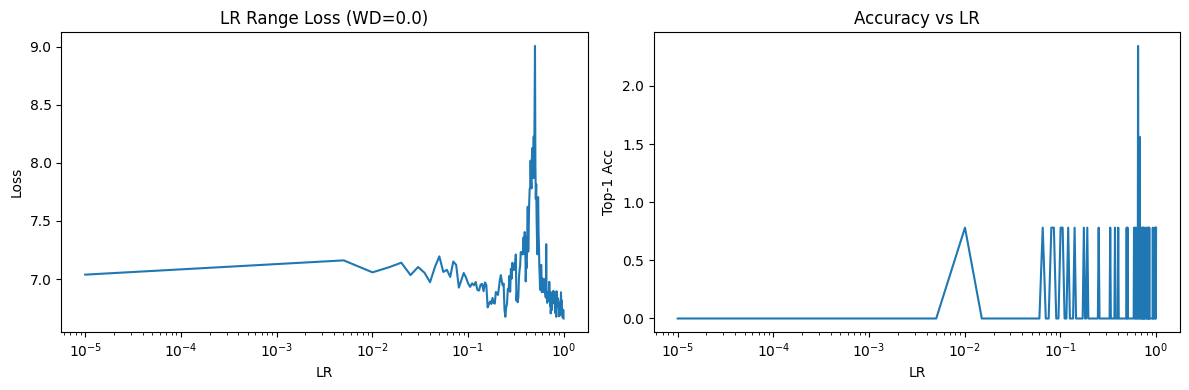

In [21]:
# Run LR range tests across a small WD grid (paper recommends checking WD interactions)
results_by_wd = {}
for wd in cfg.wd_grid:
    print(f'Running LR range test at WD={wd}...')
    res = lr_range_test(max_steps=800 if not cfg.demo_mode else 200, lr_start=1e-5, lr_end=1.0,
                        weight_decay=wd, momentum=0.9, linear=True, smoothing=0.1,
                        stop_factor=5.0)
    results_by_wd[wd] = res

# Analyze curves and pick recommended LR_min/LR_max and WD
recommendations = []
for wd, res in results_by_wd.items():
    lr_min, lr_max = suggest_lrs_from_curve(res['lrs'], res['losses'])
    last_acc = res['acc1'][-1] if len(res['acc1'])>0 else 0
    recommendations.append((wd, lr_min, lr_max, last_acc))

# Prefer lower WD under large LR if curves are stable (paper suggests ~3e-6 often best)
recommendations.sort(key=lambda t: (-(t[2]), t[0]))  # prioritize larger lr_max, then smaller wd
best_wd, best_lr_min, best_lr_max, _ = recommendations[0]
print(f'Suggested from LR tests → WD={best_wd}, LR_min≈{best_lr_min:.3e}, LR_max≈{best_lr_max:.3e}')

# Plot example curve for the best WD
res = results_by_wd[best_wd]
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(res['lrs'], res['losses']); plt.xscale('log'); plt.xlabel('LR'); plt.ylabel('Loss'); plt.title(f'LR Range Loss (WD={best_wd})')
plt.subplot(1,2,2); plt.plot(res['lrs'], res['acc1']); plt.xscale('log'); plt.xlabel('LR'); plt.ylabel('Top-1 Acc'); plt.title('Accuracy vs LR')
plt.tight_layout(); plt.show()

## 3) Configure 1Cycle schedule (LR + Momentum)
- LR: ramp up from LR_min → LR_max then down to LR_final ≈ LR_min/1000
- Momentum: inverse cycle 0.95 → 0.85 → 0.95
- Total epochs: ~20 (paper) — can adjust for your hardware

In [22]:
# Build model, optimizer, OneCycle scheduler, AMP scaler
def build_training_objects(lr_min: float, lr_max: float, wd: float):
    model = create_model(NUM_CLASSES, pretrained=False)
    criterion = LabelSmoothingCE(eps=0.1)
    optimizer = optim.SGD(model.parameters(), lr=lr_min, momentum=0.95, weight_decay=wd, nesterov=True)
    steps_per_epoch = len(train_loader)
    if cfg.demo_mode:
        steps_per_epoch = min(steps_per_epoch, cfg.max_demo_batches)
    total_steps = steps_per_epoch * cfg.epochs
    # Align OneCycle initial LR to lr_min via div_factor
    div_factor = (lr_max / lr_min) if lr_min > 0 else 25.0
    scheduler = OneCycleLR(
        optimizer,
        max_lr=lr_max,
        total_steps=total_steps,
        pct_start=0.3,
        anneal_strategy='cos',
        cycle_momentum=True,
        base_momentum=0.85,
        max_momentum=0.95,
        div_factor=div_factor,
        final_div_factor=1000.0,
    )
    scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp and cuda)
    return model, criterion, optimizer, scheduler, scaler, steps_per_epoch

# Build with suggested hyperparameters from LR test
model, criterion, optimizer, scheduler, scaler, steps_per_epoch = build_training_objects(best_lr_min, best_lr_max, best_wd)
steps_per_epoch, cfg.epochs

(16, 200)

In [23]:
# Training and evaluation utilities
def train_one_epoch(epoch: int) -> Dict[str, float]:
    model.train()
    total_loss, total_top1, total_top5, total_count = 0.0, 0.0, 0.0, 0
    optimizer.zero_grad(set_to_none=True)
    for bidx, (x, y) in enumerate(train_loader):
        if cfg.demo_mode and bidx >= cfg.max_demo_batches:
            break
        x = x.to(device, non_blocking=True)
        if cuda:
            x = x.to(memory_format=torch.channels_last)
        y = y.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=cfg.amp and cuda):
            out = model(x)
            loss = criterion(out, y) / cfg.grad_accum_steps
        scaler.scale(loss).backward()
        if (bidx + 1) % cfg.grad_accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
        top1, top5 = accuracy(out, y, topk=(1,5))
        bs = y.size(0)
        total_loss += loss.item() * cfg.grad_accum_steps * bs
        total_top1 += top1 * bs
        total_top5 += top5 * bs
        total_count += bs
    return { 'loss': total_loss/total_count, 'top1': total_top1/total_count, 'top5': total_top5/total_count }

@torch.no_grad()
def evaluate() -> Dict[str, float]:
    model.eval()
    total_loss, total_top1, total_top5, total_count = 0.0, 0.0, 0.0, 0
    for bidx, (x, y) in enumerate(val_loader):
        if cfg.demo_mode and bidx >= max(1, cfg.max_demo_batches//2):
            break
        x = x.to(device, non_blocking=True)
        if cuda:
            x = x.to(memory_format=torch.channels_last)
        y = y.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=cfg.amp and cuda):
            out = model(x)
            loss = criterion(out, y)
        top1, top5 = accuracy(out, y, topk=(1,5))
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_top1 += top1 * bs
        total_top5 += top5 * bs
        total_count += bs
    return { 'loss': total_loss/total_count, 'top1': total_top1/total_count, 'top5': total_top5/total_count }

In [24]:
# Run the full 1Cycle training
history = {'train_loss': [], 'train_top1': [], 'train_top5': [], 'val_loss': [], 'val_top1': [], 'val_top5': []}
best_val_top1 = -1.0
os.makedirs('checkpoints', exist_ok=True)
for epoch in range(cfg.epochs):
    tr = train_one_epoch(epoch)
    va = evaluate()
    history['train_loss'].append(tr['loss'])
    history['train_top1'].append(tr['top1'])
    history['train_top5'].append(tr['top5'])
    history['val_loss'].append(va['loss'])
    history['val_top1'].append(va['top1'])
    history['val_top5'].append(va['top5'])
    print(f"Epoch {epoch+1:02d}/{cfg.epochs} | Train: loss {tr['loss']:.4f}, top1 {tr['top1']:.2f}, top5 {tr['top5']:.2f} | Val: loss {va['loss']:.4f}, top1 {va['top1']:.2f}, top5 {va['top5']:.2f}")
    if va['top1'] > best_val_top1:
        best_val_top1 = va['top1']
        torch.save({'model': model.state_dict(), 'cfg': asdict(cfg)}, f'checkpoints/best_onecycle_resnet50.pth')
        print(f'  ✅ New best model saved (Top-1={best_val_top1:.2f})')

Epoch 01/200 | Train: loss 7.0853, top1 0.05, top5 0.65 | Val: loss 6.9696, top1 0.15, top5 0.55
  ✅ New best model saved (Top-1=0.15)
  ✅ New best model saved (Top-1=0.15)
Epoch 02/200 | Train: loss 7.0551, top1 0.10, top5 0.65 | Val: loss 7.0149, top1 0.10, top5 0.30
Epoch 02/200 | Train: loss 7.0551, top1 0.10, top5 0.65 | Val: loss 7.0149, top1 0.10, top5 0.30
Epoch 03/200 | Train: loss 7.0334, top1 0.20, top5 0.60 | Val: loss 7.0455, top1 0.15, top5 0.40
Epoch 03/200 | Train: loss 7.0334, top1 0.20, top5 0.60 | Val: loss 7.0455, top1 0.15, top5 0.40
Epoch 04/200 | Train: loss 7.0202, top1 0.25, top5 0.65 | Val: loss 7.0384, top1 0.15, top5 0.55
Epoch 04/200 | Train: loss 7.0202, top1 0.25, top5 0.65 | Val: loss 7.0384, top1 0.15, top5 0.55
Epoch 05/200 | Train: loss 7.0103, top1 0.25, top5 0.70 | Val: loss 6.9903, top1 0.25, top5 0.70
Epoch 05/200 | Train: loss 7.0103, top1 0.25, top5 0.70 | Val: loss 6.9903, top1 0.25, top5 0.70
  ✅ New best model saved (Top-1=0.25)
  ✅ New best 

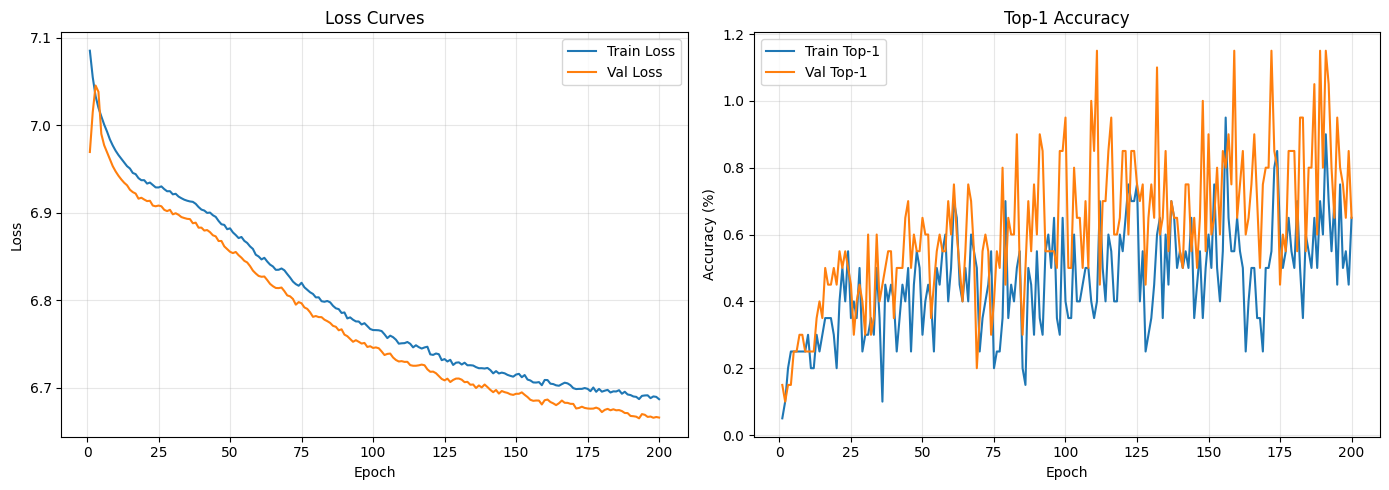

In [25]:
# Plot training curves
epochs = list(range(1, cfg.epochs+1))
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(epochs, history['train_loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curves'); plt.legend(); plt.grid(True, alpha=0.3)
plt.subplot(1,2,2)
plt.plot(epochs, history['train_top1'], label='Train Top-1')
plt.plot(epochs, history['val_top1'], label='Val Top-1')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('Top-1 Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [26]:
# Save results summary
summary = {
    'recommended': {
        'wd': best_wd,
        'lr_min': best_lr_min,
        'lr_max': best_lr_max,
        'epochs': cfg.epochs,
        'batch_size': BATCH_SIZE,
        'grad_accum_steps': cfg.grad_accum_steps
    },
    'final_val': {
        'loss': history['val_loss'][-1] if history['val_loss'] else None,
        'top1': history['val_top1'][-1] if history['val_top1'] else None,
        'top5': history['val_top5'][-1] if history['val_top5'] else None
    }
}
os.makedirs('results', exist_ok=True)
with open('results/onecycle_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "recommended": {
    "wd": 0.0,
    "lr_min": 0.0005035075376884422,
    "lr_max": 0.005035075376884422,
    "epochs": 200,
    "batch_size": 128,
    "grad_accum_steps": 2
  },
  "final_val": {
    "loss": 6.666215461730957,
    "top1": 0.65,
    "top5": 2.25
  }
}


In [27]:
# Utility: scale LR with batch size (rule-of-thumb)
def scale_lr(base_lr_max: float, batch_size: int, base_bs: int = 256):
    return base_lr_max * (batch_size / base_bs)

print('Example LR scaling:')
print('LR_max for current batch:', scale_lr(best_lr_max, BATCH_SIZE))

Example LR scaling:
LR_max for current batch: 0.002517537688442211


In [28]:
# Optional: resume from checkpoint
ckpt_path = 'checkpoints/best_onecycle_resnet50.pth'
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model'], strict=False)
    print('Loaded checkpoint for evaluation/resume.')
else:
    print('No checkpoint found to resume.')

Loaded checkpoint for evaluation/resume.


In [29]:
# Final evaluation after (optional) resume
final_metrics = evaluate()
print('Final evaluation:', final_metrics)

Final evaluation: {'loss': 6.729809047698975, 'top1': 1.15, 'top5': 2.65}


In [30]:
# Cleanup: release GPU memory (useful on constrained AWS instances)
del model, criterion, optimizer, scheduler, scaler
torch.cuda.empty_cache()
print('Freed GPU memory.')

Freed GPU memory.
